In [2]:
#This notebook plots figures from the experiment 1 in our work
#Goal : do NMF on real matrices on dirac-3 for 1x1,2x2,3x3,4x4 matrices and compare with sklearn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF as NMF_sklearn
from scipy import stats

### Dirac3 experiment 1

In [3]:
#Initializing data structures for gathering the results
rel_error_dict = {}
rel_error_mad_dict = {}
rel_error_median_dict = {}

for relaxation_schedule in [1,2,3]:
    rel_error_mad_dict[(relaxation_schedule)] = []
    rel_error_median_dict[(relaxation_schedule)] = []
    for n in [1,2,3,4]:
        rel_error_dict[(relaxation_schedule,n)] = []
        for i in range(0,100):
            res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
            res_filepath = "./test_matrices/dirac3_exp1/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

            f = np.load(res_filepath)
            
            rel_error_dict[(relaxation_schedule,n)].append(float(f['rel_error_potts']))
            
            f.close()
        #Get the median
        rel_error_median_dict[(relaxation_schedule)].append( np.median(rel_error_dict[(relaxation_schedule,n)] ))
        #Get the mad
        rel_error_mad_dict[(relaxation_schedule)].append( stats.median_abs_deviation(rel_error_dict[(relaxation_schedule,n)] ))


In [4]:
#Now for the sklearn data
rel_error_mad_dict['sklearn'] = []
rel_error_median_dict['sklearn'] = []
relaxation_schedule = 3
for n in [1,2,3,4]:
    rel_error_dict[('sklearn',n)] = []
    for i in range(0,100):
        res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
        res_filepath = "./test_matrices/dirac3_exp1/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

        f = np.load(res_filepath)
            
        rel_error_dict[('sklearn',n)].append(float(f['rel_error_sklearn']))
    #Get the median
    rel_error_median_dict[('sklearn')].append( np.median(rel_error_dict[('sklearn',n)] ))
    #Get the mad
    rel_error_mad_dict[('sklearn')].append( stats.median_abs_deviation(rel_error_dict[('sklearn',n)] ))    

In [5]:
#Now for the fusion data
#Fusion : dirac-3 results as inputs to sklearn
for relaxation_schedule in [1,2,3]:
    rel_error_mad_dict[(relaxation_schedule,'fusion')] = []
    rel_error_median_dict[(relaxation_schedule,'fusion')] = []
    for n in [1,2,3,4]:
        rel_error_dict[(relaxation_schedule,'fusion',n)] = []
        for i in range(0,100):
            res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
            res_filepath = "./test_matrices/dirac3_exp1/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

            f = np.load(res_filepath)
            
            rel_error_dict[(relaxation_schedule,'fusion',n)].append(float(f['rel_error_fusion']))
            
            f.close()
        #Get the median
        rel_error_median_dict[(relaxation_schedule,'fusion')].append( np.median(rel_error_dict[(relaxation_schedule,'fusion',n)] ))
        #Get the mad
        rel_error_mad_dict[(relaxation_schedule,'fusion')].append( stats.median_abs_deviation(rel_error_dict[(relaxation_schedule,'fusion',n)] ))   

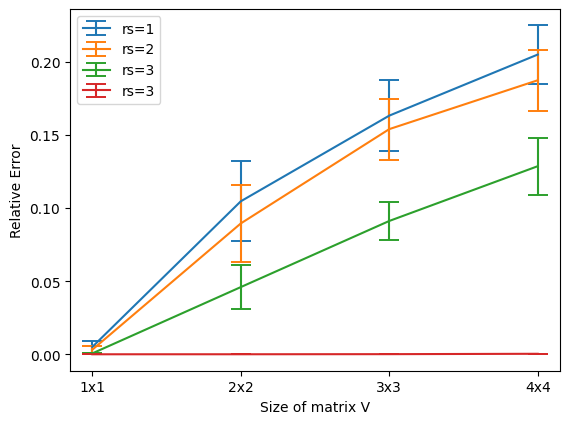

In [6]:
#Rudimentary line plot for the relative errors
fig, ax = plt.subplots()

ax.errorbar([1,2,3,4],rel_error_median_dict[1],yerr=rel_error_mad_dict[1],label='rs=1',solid_capstyle='projecting', capsize=7, capthick =1.4)
ax.errorbar([1,2,3,4],rel_error_median_dict[2],yerr=rel_error_mad_dict[2],label='rs=2',solid_capstyle='projecting', capsize=7, capthick =1.4)
ax.errorbar([1,2,3,4],rel_error_median_dict[3],yerr=rel_error_mad_dict[3],label='rs=3',solid_capstyle='projecting', capsize=7, capthick =1.4)
ax.errorbar([1,2,3,4],rel_error_median_dict['sklearn'],yerr=rel_error_mad_dict['sklearn'],label='rs=3',solid_capstyle='projecting', capsize=7, capthick =1.4)


fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)

ax.legend()
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax.set_xlabel('Size of matrix V')
ax.set_ylabel('Relative Error')
ax.set_xticks(np.arange(1,5))
ax.set_xticklabels(['1x1','2x2','3x3','4x4'])
plt.show()

### Now let us plot with curve fitting

In [7]:
#Using curve fit from scipy
from scipy.optimize import curve_fit


In [8]:
#Define some curve fitting functions if necessary
def exp_curve(x, a, b):
    return a * np.exp(-b * x)


def poly_curve(x,a): 
    return  a*np.power(x,0.85) #a*np.power(x,0.85)#(x**3)#a*x + b*(x**2) + c*(x**3) + d*(x**4) #+ e*(x**5)

def log_curve(x,a):
    return a* np.log(x)
    
def plateau_curve(x,a,b):
    return (a*x)/(b+x)

def logistic_curve(x,a,b,c):
    return (b)/(c + np.exp(-a*x))

In [20]:
#Creating x values for all the curves (here its as the square of the dimensions)
#Because the square of the the dimension roughly correspond to the number of variables involved
x_curve = np.array([i**2 for i in range(1,5)])
#Parameters for different types of curves
median_plateau_opt = [None for i in range(3)]
median_exp_opt = [None for i in range(3)]
median_poly_opt = [None for i in range(3)]
median_log_opt = [None for i in range(3)]
median_logistic_opt = [None for i in range(3)]

In [21]:
#Trying out different curves
for i in range(3):
    median_exp_opt[i], _ = curve_fit(exp_curve, x_curve, rel_error_median_dict[i+1])
    median_poly_opt[i], _ = curve_fit(poly_curve, x_curve, rel_error_median_dict[i+1])
    median_log_opt[i], _ = curve_fit(log_curve, x_curve, rel_error_median_dict[i+1])
    median_plateau_opt[i], _ = curve_fit(plateau_curve, x_curve, rel_error_median_dict[i+1])
    median_logistic_opt[i], _ = curve_fit(logistic_curve, x_curve, rel_error_median_dict[i+1])

In [22]:
#Output values for different curves
y_exp = []
y_poly = []
y_log = []
y_plateau = []
y_logistic = []
error_exp = []
error_poly = []
error_log = []
error_plateau = []
error_logistic = []

#Populating the lists
for rs in [1,2,3]: #rs is relaxation schedule
    y_exp.append([])
    y_poly.append([])
    y_log.append([])
    y_plateau.append([])
    y_logistic.append([])
    error_exp.append([])
    error_poly.append([])
    error_log.append([])
    error_plateau.append([])
    error_logistic.append([])
    for i in x_curve:
        y_exp[rs-1].append(exp_curve(i,*median_exp_opt[rs-1]))
        y_poly[rs-1].append(poly_curve(i,*median_poly_opt[rs-1]))
        y_log[rs-1].append(log_curve(i,*median_log_opt[rs-1]))
        y_plateau[rs-1].append(plateau_curve(i,*median_plateau_opt[rs-1]))
        y_logistic[rs-1].append(logistic_curve(i,*median_logistic_opt[rs-1]))
    #Calculate error
    error_exp[rs-1] = np.linalg.norm( np.array(rel_error_median_dict[rs]) - np.array( y_exp[rs-1]) )
    error_poly[rs-1] = np.linalg.norm( np.array(rel_error_median_dict[rs]) - np.array( y_poly[rs-1]) )
    error_log[rs-1] = np.linalg.norm( np.array(rel_error_median_dict[rs]) - np.array( y_log[rs-1]) )
    error_plateau[rs-1] = np.linalg.norm( np.array(rel_error_median_dict[rs]) - np.array( y_plateau[rs-1]) )
    error_logistic[rs-1] = np.linalg.norm( np.array(rel_error_median_dict[rs]) - np.array( y_logistic[rs-1]) )




In [23]:
print("Means")
print("Exp curve:",np.mean(error_exp))
print("Poly curve:",np.mean(error_poly))
print("Log curve:",np.mean(error_log))
print("Plateau curve:",np.mean(error_plateau))
print("Logistic curve:",np.mean(error_logistic))

Means
Exp curve: 0.06222621685090255
Poly curve: 0.037407378527495656
Log curve: 0.009893595182745697
Plateau curve: 0.021840726887796067
Logistic curve: 0.02323919795729502


In [24]:
print("Medians")
print("Exp curve:",np.median(error_exp))
print("Poly curve:",np.median(error_poly))
print("Log curve:",np.median(error_log))
print("Plateau curve:",np.median(error_plateau))
print("Logistic curve:",np.median(error_logistic))

Medians
Exp curve: 0.07167462674553753
Poly curve: 0.045190226466882845
Log curve: 0.0073996118935083085
Plateau curve: 0.025756827186464767
Logistic curve: 0.023415304868820364


In [25]:
#We choose log because it has the best fit
#Calculate y_plot for log
y_plot1 = []
y_plot2 = []
y_plot3 = []
x_plot = np.arange(1,4.1,0.1)
for item in x_plot:
    y_plot1.append(log_curve(item**2,*median_log_opt[0]))
    y_plot2.append(log_curve(item**2,*median_log_opt[1]))
    y_plot3.append(log_curve(item**2,*median_log_opt[2]))

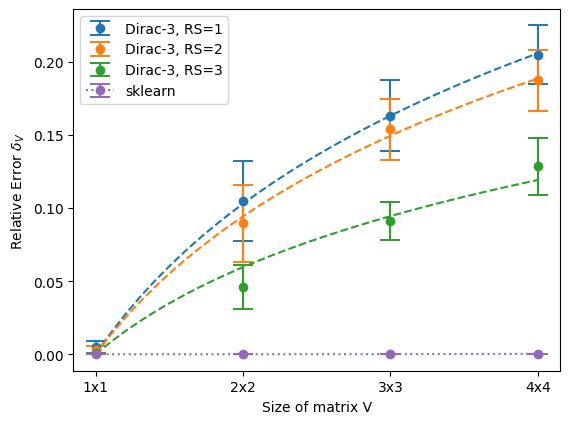

In [26]:
fig, ax = plt.subplots()

ax.errorbar([1,2,3,4],rel_error_median_dict[1],yerr=rel_error_mad_dict[1],label='Dirac-3, RS=1',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:blue')
ax.plot(x_plot, y_plot1,color='tab:blue',linestyle="--")
ax.errorbar([1,2,3,4],rel_error_median_dict[2],yerr=rel_error_mad_dict[2],label='Dirac-3, RS=2',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:orange')
ax.plot(x_plot, y_plot2,color='tab:orange',linestyle="--")

ax.errorbar([1,2,3,4],rel_error_median_dict[3],yerr=rel_error_mad_dict[3],label='Dirac-3, RS=3',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:green')
ax.plot(x_plot, y_plot3,color='tab:green',linestyle="--")


ax.errorbar([1,2,3,4],rel_error_median_dict['sklearn'],yerr=rel_error_mad_dict['sklearn'],label='sklearn',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt=":o",color='tab:purple')

fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)

ax.legend()
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax.set_xlabel('Size of matrix V')
ax.set_ylabel('Relative Error $\delta_{V}$')
ax.set_xticks(np.arange(1,5))
ax.set_xticklabels(['1x1','2x2','3x3','4x4'])
plt.savefig("plot_exp1_relerr.pdf")
plt.show()

Good! Now lets analyze times

In [27]:
#Times for square matrices
time_dict = {}
time_mad_dict = {}
time_median_dict = {}

for relaxation_schedule in [1,2,3]:
    time_mad_dict[(relaxation_schedule)] = []
    time_median_dict[(relaxation_schedule)] = []
    for n in [1,2,3,4]:
        time_dict[(relaxation_schedule,n)] = []
        for i in range(0,100):
            res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
            res_filepath = "./test_matrices/dirac3_exp1/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

            f = np.load(res_filepath)
            
            time_dict[(relaxation_schedule,n)].append(0.1*float(f['device_usage_s'])) #0.1 because we need time per run
            
            f.close()
        #Get the median
        time_median_dict[(relaxation_schedule)].append( np.median(time_dict[(relaxation_schedule,n)] ))
        #Get the mad
        time_mad_dict[(relaxation_schedule)].append( stats.median_abs_deviation(time_dict[(relaxation_schedule,n)] ))


In [28]:
#Similar curve fitting process to the one for error
x_curve = np.array([i**2 for i in range(1,5)])
tmedian_plateau_opt = [None for i in range(3)]
tmedian_exp_opt = [None for i in range(3)]
tmedian_poly_opt = [None for i in range(3)]
tmedian_log_opt = [None for i in range(3)]
tmedian_logistic_opt = [None for i in range(3)]

In [29]:
#Trying out different curves
for i in range(3):
    tmedian_exp_opt[i], _ = curve_fit(exp_curve, x_curve, time_median_dict[i+1])
    tmedian_poly_opt[i], _ = curve_fit(poly_curve, x_curve, time_median_dict[i+1])
    tmedian_log_opt[i], _ = curve_fit(log_curve, x_curve, time_median_dict[i+1])
    tmedian_plateau_opt[i], _ = curve_fit(plateau_curve, x_curve, time_median_dict[i+1])
    tmedian_logistic_opt[i], _ = curve_fit(logistic_curve, x_curve, time_median_dict[i+1])

C:\Users\User\AppData\Local\Temp\ipykernel_18628\1175117471.py:16: RuntimeWarning: overflow encountered in exp
  return (b)/(c + np.exp(-a*x))


In [30]:
ty_exp = []
ty_poly = []
ty_log = []
ty_plateau = []
ty_logistic = []
terror_exp = []
terror_poly = []
terror_log = []
terror_plateau = []
terror_logistic = []
for rs in [1,2,3]:
    ty_exp.append([])
    ty_poly.append([])
    ty_log.append([])
    ty_plateau.append([])
    ty_logistic.append([])
    terror_exp.append([])
    terror_poly.append([])
    terror_log.append([])
    terror_plateau.append([])
    terror_logistic.append([])
    for i in x_curve:
        ty_exp[rs-1].append(exp_curve(i,*tmedian_exp_opt[rs-1]))
        ty_poly[rs-1].append(poly_curve(i,*tmedian_poly_opt[rs-1]))
        ty_log[rs-1].append(log_curve(i,*tmedian_log_opt[rs-1]))
        ty_plateau[rs-1].append(plateau_curve(i,*tmedian_plateau_opt[rs-1]))
        ty_logistic[rs-1].append(logistic_curve(i,*tmedian_logistic_opt[rs-1]))
    #Calculate error
    terror_exp[rs-1] = np.linalg.norm( np.array(time_median_dict[rs]) - np.array( ty_exp[rs-1]) )
    terror_poly[rs-1] = np.linalg.norm( np.array(time_median_dict[rs]) - np.array( ty_poly[rs-1]) )
    terror_log[rs-1] = np.linalg.norm( np.array(time_median_dict[rs]) - np.array( ty_log[rs-1]) )
    terror_plateau[rs-1] = np.linalg.norm( np.array(time_median_dict[rs]) - np.array( ty_plateau[rs-1]) )
    terror_logistic[rs-1] = np.linalg.norm( np.array(time_median_dict[rs]) - np.array( ty_logistic[rs-1]) )




In [31]:
print("Means")
print("Exp curve:",np.mean(terror_exp))
print("Poly curve:",np.mean(terror_poly))
print("Log curve:",np.mean(terror_log))
print("Plateau curve:",np.mean(terror_plateau))
print("Logistic curve:",np.mean(terror_logistic))

Means
Exp curve: 0.36424852391027257
Poly curve: 4.112913575320963
Log curve: 5.639164806966485
Plateau curve: 3.599010178133645
Logistic curve: 0.31205829797983003


In [32]:
print("Medians")
print("Exp curve:",np.median(terror_exp))
print("Poly curve:",np.median(terror_poly))
print("Log curve:",np.median(terror_log))
print("Plateau curve:",np.median(terror_plateau))
print("Logistic curve:",np.median(terror_logistic))

Medians
Exp curve: 0.10952684200522848
Poly curve: 3.548638501172575
Log curve: 4.832241217503341
Plateau curve: 3.0866671929092577
Logistic curve: 0.06418970494976468


In [33]:
#Although logistic curves have a better fit, we choose exp because they are more in line with what we expect
#for the optimization times for NP-Hard problems
#Calculate y_plot for exp
ty_plot1 = []
ty_plot2 = []
ty_plot3 = []
x_plot = np.arange(1,4.1,0.1)
for item in x_plot:
    ty_plot1.append(exp_curve(item**2,*tmedian_exp_opt[0]))
    ty_plot2.append(exp_curve(item**2,*tmedian_exp_opt[1]))
    ty_plot3.append(exp_curve(item**2,*tmedian_exp_opt[2]))

In [34]:
#Lets get sklearn
time_mad_dict['sklearn'] = []
time_median_dict['sklearn'] = []


for n in [1,2,3,4]:
    time_dict[('sklearn',n)] = []
    for i in range(100):
        res_filename = 'sklearn_tm_res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+".npy"
        res_filepath = "./test_matrices/dirac3_exp1/size_" + str(n) + "x" + str(n) + "/results/" + res_filename 
        
        time_dict[('sklearn',n)].append(0.1*float(np.load(res_filepath)))
     #Get the median
    time_median_dict['sklearn'].append( np.median(time_dict[('sklearn',n)] ))
    #Get the mad
    time_mad_dict[('sklearn')].append( stats.median_abs_deviation(time_dict[('sklearn',n)] ))
    

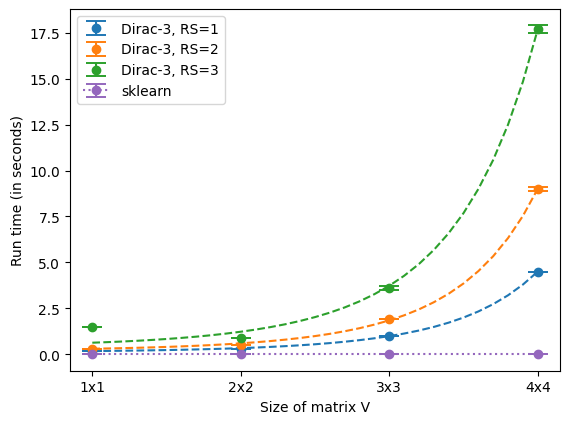

In [35]:
#Plot for times
fig, ax = plt.subplots()

ax.errorbar([1,2,3,4],time_median_dict[1],yerr=time_mad_dict[1],label='Dirac-3, RS=1',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:blue')
ax.plot(x_plot, ty_plot1,color='tab:blue',linestyle="--")
ax.errorbar([1,2,3,4],time_median_dict[2],yerr=time_mad_dict[2],label='Dirac-3, RS=2',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:orange')
ax.plot(x_plot, ty_plot2,color='tab:orange',linestyle="--")

ax.errorbar([1,2,3,4],time_median_dict[3],yerr=time_mad_dict[3],label='Dirac-3, RS=3',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt="o",color='tab:green')
ax.plot(x_plot, ty_plot3,color='tab:green',linestyle="--")

ax.errorbar([1,2,3,4],time_median_dict['sklearn'],yerr=time_mad_dict['sklearn'],label='sklearn',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt=":o",color='tab:purple')


fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)

ax.legend()
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax.set_xlabel('Size of matrix V')
ax.set_ylabel('Run time (in seconds)')
ax.set_xticks(np.arange(1,5))
ax.set_xticklabels(['1x1','2x2','3x3','4x4'])
plt.savefig("plot_exp1_time.pdf")
plt.show()